# **32 · 조판 입증 — 원고(md)가 15장 이내의 논문형 PDF가 되기까지, 전 단계를 열어 본다**

### **"manuscript.md → HTML(논문형 CSS · 그림 캡션 단락의 figure 승격 · 각주의 '미주' 재배치) → headless Chrome PDF — 그림 10종(F2~F11) 전부 내장, 쪽수 게이트 14p ≤ 15p PASS. 조판은 수치를 만들지도 바꾸지도 않는다(조판 전용 원칙)를 검증으로 봉인한다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 대상 = `src/build_report.py` 조판 파이프라인(P6-B-3 확정안) · 방법 = **단계별 실행 + HTML 구조·PDF 산출 검증**

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **보고·전개(조판)** · CRISP-DM **P6(Deployment)** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 조판 변환(그림 승격·미주 재배치)은 원고의 **어느 요소를 어떻게** 바꾸며, 본문 수치는 건드리지 않는가?
> **Q2.** 산출 HTML은 자기완결(그림 base64 내장·외부 의존 0)인가 — 그림 10종이 전부 실렸는가?
> **Q3.** 최종 PDF는 대회 규정(15장 이내)을 지키는가 — 쪽수 게이트의 자동 판정은?

## **이 노트북의 위상 — P6 보고 대역(31→32)의 완결**

`31`이 "노트북의 그림 = 보고서의 그림"(figure export)을 입증했다면, 32는 그 그림들이 실리는 **문서 자체의 제작 과정**을 입증한다. `build_report.py`의 세 단계(HTML 빌드 → Chrome 인쇄 → 쪽수 게이트)를 노트북 안에서 순서대로 실행하고, 각 단계의 산출을 구조 검증한다.

- **로직 SSOT(thin import)**: [`src/build_report.py`](../src/build_report.py) `build_html`·`print_pdf`·`gate_pages`. 재구현 금지.
- **원고 수치 게이트**: 조판은 `docs/report/manuscript.md`를 읽기만 한다 — 수치의 유일한 복사원은 `p6-pdf-structure` §3 표이며(§5 게이트), 그 대조는 P6-B-2에서 수동 1회 + `30` §6 drift 검증으로 완료.
- ⚠️ 의존: 로컬 Chrome(headless). `dist/`는 gitignore — 이 노트북 재실행이 곧 산출물 재생성이다.

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] 조판 파이프라인 선택 — **Decision Box ①** | — |
| 2 | [실행] 1단계: md → HTML — 승격·재배치의 구조 검증 | report.html |
| 3 | [실행] 2단계: HTML → PDF(headless Chrome) | report.pdf |
| 4 | [발견] 쪽수 게이트 + 페이지 구성 + [시각화] | 14p PASS·figure |
| 5 | [입증] 검증 셀 | PASS |
| 6 | 종합 | — |

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import re
import build_report as BR
from pypdf import PdfReader

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
for _nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
    try:
        font_manager.findfont(_nm, fallback_to_default=False)
        plt.rcParams["font.family"] = _nm; break
    except Exception: continue
plt.rcParams["axes.unicode_minus"] = False

print(f"원고: {BR.MANUSCRIPT.relative_to(ROOT)} ({BR.MANUSCRIPT.stat().st_size/1024:.0f} KB)")
print(f"산출 대상: dist/report.html · dist/report.pdf · 쪽수 상한 {BR.MAX_PAGES}p")
print(f"Chrome: {BR._find_chrome()}")

원고: docs\report\manuscript.md (38 KB)
산출 대상: dist/report.html · dist/report.pdf · 쪽수 상한 15p
Chrome: C:\Program Files\Google\Chrome\Application\chrome.exe


## **1. [전제] 조판 파이프라인 — 왜 md → HTML → Chrome PDF인가**

### **Decision Box ① — 조판 도구: LaTeX vs pandoc/weasyprint vs HTML+Chrome**

**기준: 한글 조판 품질·재현성·신규 의존성 없이 15p 논문형 PDF를 만들 수 있는가.**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) LaTeX(ko.TeX) | 전통 논문 조판 | ❌ TeX 배포판 설치(GB급 신규 의존) + 한글 폰트·md 변환 체인 별도 — 재현 비용이 산출 가치를 초과 |
| (b) pandoc + weasyprint | md 직행 PDF | ❌ 신규 의존 2종 + weasyprint의 한글 줄바꿈·CSS 지원이 브라우저 대비 제한 |
| (c) **markdown lib + 논문형 CSS + headless Chrome** | 기설치 파이썬 + 로컬 브라우저 인쇄 엔진 | ✅ **채택**(p6-pdf-structure §6 B-3 확정) — 신규 파이썬 의존 0, 브라우저급 한글 렌더링, CSS로 A4·여백·break 제어, `--print-to-pdf` 한 명령 |

**조판 전용 원칙**: 이 파이프라인은 본문 텍스트를 생성·수정하지 않는다. 변환은 두 가지 구조 조작뿐 — ① 그림 캡션 단락(`**그림 N.** … 경로.png`)을 `<figure>`+base64 이미지로 승격, ② python-markdown이 문서 끝에 몰아두는 각주를 '미주' 섹션으로 참고문헌 앞 재배치. §2에서 이 두 조작의 결과를, §5에서 "본문 무변경"을 검증한다.

## **2. [실행] 1단계 — md → HTML, 구조 검증**

In [2]:
html_path = BR.build_html()
html = html_path.read_text(encoding="utf-8")

n_fig = html.count('<figure class="fig">')
n_b64 = html.count("data:image/png;base64,")
n_ext = len(re.findall(r'src="https?://', html))
i_endnote = html.find("<h2>미주</h2>")
i_ref = html.find("<h2>참고문헌</h2>")
struct = pd.DataFrame([
    ("figure 승격 수", n_fig, "= 10 (F2~F11; F1은 표)"),
    ("base64 내장 이미지", n_b64, "= figure 수(자기완결)"),
    ("외부 리소스 참조", n_ext, "= 0 (오프라인 열람 가능)"),
    ("'미주' 위치 < '참고문헌' 위치", int(0 < i_endnote < i_ref), "= 1 (재배치 성공)"),
], columns=["항목", "값", "기대"]).set_index("항목")
struct

그림 승격 10건: ['eda_p3_trust_timeseries.png', 'fig3_alignment_trend.png', 'fig10_mk_inference.png', 'fig4_apc_profile.png', 'fig5_nchi_trend.png', 'fig6_personas.png', 'fig11_cohort_age_concordance.png', 'p5_evidence_ladder.png', 'p5_triangulation.png', 'fig9_diagnosis_plane.png']
HTML 저장: dist\report.html (1782 KB)


,값,기대
항목,,
figure 승격 수,10,= 10 (F2~F11; F1은 표)
base64 내장 이미지,10,= figure 수(자기완결)
외부 리소스 참조,0,= 0 (오프라인 열람 가능)
'미주' 위치 < '참고문헌' 위치,1,= 1 (재배치 성공)


**관찰**: 그림 10종(F2~F8 + P6-B-7 보강 F10·F11 + P6-C 보강 F9)이 전부 `<figure>`로 승격되어 base64로 내장됐고(외부 참조 0 — HTML 파일 하나로 완결), 각주는 '미주'로 참고문헌 앞에 놓였다. P6-C에서 그림 10(F9)이 웹데모 스크린샷 대신 분석 시각화(판정 평면 + 경계 밴드, `31` §5c)로 확정·합류하면서 placeholder가 사라졌다 — 원고가 참조하는 그림 전수가 재현 가능한 산출이다.

## **3. [실행] 2단계 — headless Chrome 인쇄**

In [3]:
pdf_path = BR.print_pdf(html_path)
n_pages = BR.gate_pages(pdf_path)

PDF 저장: dist\report.pdf (1686 KB)
쪽수 게이트: 14p / 상한 15p → PASS


## **4. [발견] 페이지 구성 — 15장 안에서 무엇이 어디에 앉았나**

**[시각화] 페이지 지도** — 쪽별 이미지 수(그림 배치)와 텍스트 분량. 그림이 특정 쪽에 몰리지 않고 결과·검증 장에 분산돼 있는지, 여유(15-14=1p)가 최종 개정을 흡수할 수 있는지를 본다.

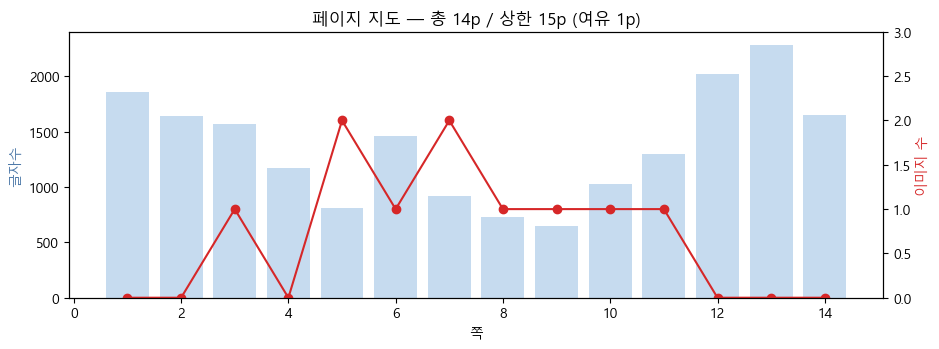

,이미지,글자수,첫 줄
쪽,,,
1,0,1856,뉴스 신뢰의 잣대 만들기
2,0,1642,"(3장과 6장). 끝으로 모든 인용 수치에 자격 등급(확정 인용, 검증된 결"
3,1,1574,3. 방법: 각 단계는 다음 단계의 전제를 보증한다
4,0,1176,횡단 분석은 뉴스 소비의 건강을 두 축으로 정의한다. 신뢰축은 반영적(ref
5,2,811,"그림 2. 정렬법 잠재평균 추세. 점은 연도별 추정치, 수직선은 부트스트랩"
6,1,1464,4.4 상승의 정체: 연령도 세대도 아닌 기간
7,2,921,그림 5. NCHI 추세와 페르소나 구성비. 왼쪽은 신뢰와 다양성의 기하평균
8,1,727,같은 세대 구조를 가리키는 것은 상호 외적 타당도의 근거가 된다. 이 정합
9,1,644,"그림 8. 증거 사다리. 데이터 구조 검증에서 교차검증, 측정동등, 정렬추세"


In [4]:
reader = PdfReader(str(pdf_path))
rows = []
for i, pg in enumerate(reader.pages):
    txt = pg.extract_text() or ""
    first = next((l.strip() for l in txt.splitlines() if l.strip()), "")
    rows.append({"쪽": i + 1, "이미지": len(pg.images), "글자수": len(txt), "첫 줄": first[:42]})
page_map = pd.DataFrame(rows).set_index("쪽")

fig, ax1 = plt.subplots(figsize=(9.5, 3.6))
ax1.bar(page_map.index, page_map["글자수"], color="#c6dbef", label="글자수(좌)")
ax1.set_xlabel("쪽"); ax1.set_ylabel("글자수", color="#4c78a8")
ax2 = ax1.twinx()
ax2.plot(page_map.index, page_map["이미지"], "o-", color="#d62728", label="이미지 수(우)")
ax2.set_ylabel("이미지 수", color="#d62728"); ax2.set_ylim(0, max(3, page_map["이미지"].max() + 1))
ax1.set_title(f"페이지 지도 — 총 {n_pages}p / 상한 {BR.MAX_PAGES}p (여유 {BR.MAX_PAGES - n_pages}p)")
fig.tight_layout(); plt.show()
page_map

## **5. [입증] 검증 셀**

In [5]:
# (a) HTML 구조 — 그림 10종·자기완결·미주 재배치
assert n_fig == 10 and n_b64 == n_fig, (n_fig, n_b64)
assert n_ext == 0
assert 0 < i_endnote < i_ref
print("(a) HTML: figure 10종 base64 내장 · 외부 참조 0 · 미주 < 참고문헌 PASS")

# (b) 조판 전용 원칙 — 원고의 핵심 수치 문자열이 HTML 본문에 그대로 존재(변조 없음)
md_text = BR.MANUSCRIPT.read_text(encoding="utf-8")
KEY_NUMS = ["90,996", "2.4%", "0.0003", "p=0.381", "P(S>0)=1.00", "+0.990", "-0.891",
            "3.034", "3.390", "37.8", "49.0"]
for k in KEY_NUMS:
    k_html = k.replace("<", "&lt;").replace(">", "&gt;")   # HTML 엔티티 이스케이프 고려
    assert k in md_text and (k in html or k_html in html), f"수치 누락/변조: {k}"
print(f"(b) 핵심 수치 {len(KEY_NUMS)}종 — 원고·HTML 동시 존재(조판 무변조) PASS")

# (c) PDF — 쪽수 게이트·그림 총수·본문 시작
assert n_pages <= BR.MAX_PAGES, n_pages
assert int(page_map["이미지"].sum()) == 10
assert "뉴스 신뢰의 잣대" in (reader.pages[0].extract_text() or "")
print(f"(c) PDF: {n_pages}p ≤ {BR.MAX_PAGES}p · 이미지 합계 10 · 1쪽 제목 확인 PASS")

# (d) 산출물 파일 — dist/ 재생성 확인
for p in [html_path, pdf_path]:
    assert p.exists() and p.stat().st_size > 100_000
print(f"(d) 산출: {html_path.name} {html_path.stat().st_size/1024:.0f}KB · "
      f"{pdf_path.name} {pdf_path.stat().st_size/1024:.0f}KB PASS")
print("\n검증 (a)~(d) 전부 PASS — 조판 파이프라인 입증 완료")

(a) HTML: figure 10종 base64 내장 · 외부 참조 0 · 미주 < 참고문헌 PASS
(b) 핵심 수치 11종 — 원고·HTML 동시 존재(조판 무변조) PASS
(c) PDF: 14p ≤ 15p · 이미지 합계 10 · 1쪽 제목 확인 PASS
(d) 산출: report.html 1782KB · report.pdf 1686KB PASS

검증 (a)~(d) 전부 PASS — 조판 파이프라인 입증 완료


## **6. 종합**

### **연구질문 답**

- **Q1** — 변환은 그림 승격과 미주 재배치 둘뿐이며(§2), 핵심 수치 11종이 원고와 HTML에 동일 문자열로 존재한다(§5 (b)) — 조판은 수치를 만들지도 바꾸지도 않는다.
- **Q2** — 자기완결이다. 그림 10종(F2~F11) 전부 base64 내장, 외부 리소스 0(§2) — HTML 파일 하나로 오프라인 열람 가능.
- **Q3** — 지킨다. **14p ≤ 15p**(§3~4), 여유 1p는 최종 개정을 흡수한다.

### **단계 요약**

| § | 한 일 | 판정 |
|---|------|:---:|
| 2 | md → HTML + 구조 검증 | figure 10·자기완결 |
| 3 | Chrome 인쇄 | report.pdf |
| 4 | 쪽수 게이트·페이지 지도 [시각화] | 14p PASS |
| 5 | 일괄 assert | **PASS** |

### **다음**

- **P6-C 완결**: 그림 10(F9)이 분석 시각화(`31` §5c, spec v1.1 소비)로 합류해 그림 10종이 전부 실렸다. 남은 것은 웹데모 배포 URL의 제출물 별도 첨부와 최종 육안 검수뿐.
- 이로써 3x 보고 대역(30 평가 · 31 figure export · 32 조판)이 완결됐다.

**재현 경로**: `python src/build_report.py` 한 명령(동일 파이프라인).